In [1]:
%env SPECTRAL_CONNECTIVITY_ENABLE_GPU=true

env: SPECTRAL_CONNECTIVITY_ENABLE_GPU=true


In [2]:
import os

cuda_bin = r"C:\Users\zhaoz\miniforge3\envs\lfp_env\Library\bin"

# Add CUDA DLL folder to Windows DLL search path
os.add_dll_directory(cuda_bin)

# Add it to PATH for packages that search PATH
os.environ["PATH"] = cuda_bin + os.pathsep + os.environ["PATH"]

# Enable GPU mode for spectral_connectivity
os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"] = "true"

print("CUDA DLL path added:", cuda_bin)
print("GPU flag:", os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"])

CUDA DLL path added: C:\Users\zhaoz\miniforge3\envs\lfp_env\Library\bin
GPU flag: true


In [3]:
import cupy as cp

x = cp.array([1, 2, 3])
print(cp.linalg.norm(x))
cp.cuda.Stream.null.synchronize()
print("VS Code Jupyter GPU calculation worked")

c:\Users\zhaoz\miniforge3\envs\lfp_env\Lib\site-packages\cupy\_environment.py:275: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


3.7416573867739413
VS Code Jupyter GPU calculation worked


In [4]:
os.chdir(r'C:\Users\zhaoz\Desktop\Research\SocialMemory\diff_fam_social_memory_ephys')
import cupy as xp
from cupyx.scipy.fft import ifft
from cupyx.scipy.sparse.linalg import svds
from spectral_connectivity import Multitaper, Connectivity
import importlib
import pandas as pd
from itertools import combinations
from bidict import bidict
import lfp.lfp_analysis.LFP_collection as LFP_collection
import pickle 
def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl
    Returns:
        none
    """
    with open(file_name, "wb") as file:
        pickle.dump(thing_to_pickle, file)
def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, "rb") as file:
        return pickle.load(file)

df = pd.read_excel(r"lfp\input\channel_mapping.xlsx")
spike_cols = [col for col in df.columns if 'spike_interface_' in col.lower()]
print(df)

# # Extract brain regions from column names
# # Assumes format 'spike_interface_REGION'
# brain_regions = [col.split('spike_interface_')[1] for col in spike_cols]

# # Create nested dictionary
# subject_to_channel_dict = {}







# for _, row in df.iterrows():
#     subject = row['Subject'].astype(str)
#     # Initialize inner dictionary for this subject
#     subject_to_channel_dict[subject] = {}
    
#     # Populate inner dictionary with brain region: spike value pairs
#     for col, region in zip(spike_cols, brain_regions):
#         subject_to_channel_dict[subject][region] = int(row[col])
behavior_dicts = {}

def make_recording_to_subj_dict(data_path):
    recording_to_subject = {}
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('merged.rec'):
                subject = str((file.split("_")[-2]).replace('-', '.'))
                recording_to_subject[file] = subject
                behavior_dicts[file] = {}
    return recording_to_subject

# def process(data_path):
#     recording_to_subject = make_recording_to_subj_dict(data_path)
#     print(recording_to_subject)
#     collection = LFP_collection.LFPCollection(subject_to_channel_dict, data_path, recording_to_subject, 4)
#     #collection.process()
#     return collection    
    




c:\Users\zhaoz\miniforge3\envs\lfp_env\Lib\site-packages\cupyx\scipy\__init__.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  import scipy as _scipy
c:\Users\zhaoz\miniforge3\envs\lfp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Cohort  Subject  eib_mPFC  eib_vHPC  eib_BLA  eib_LH  eib_MD  \
0       1      6.1       NaN        15       14      13      31   
1       1      6.2       NaN        15       14      13      31   
2       1      6.3       NaN        15       14      13      31   
3       1      6.4       NaN        15       14      13      31   
4       2      1.1       NaN        16       17      18      19   
5       2      1.2       NaN        31       30      29      28   
6       2      1.3       NaN        15       14      13      12   
7       2      1.4       NaN        15       14      13      12   

   spike_interface_mPFC  spike_interface_vHPC  spike_interface_BLA  \
0                  21.0                  15.0                 14.0   
1                   NaN                   NaN                  NaN   
2                   NaN                   NaN                  NaN   
3                   NaN                   NaN                  NaN   
4                   5.0                  31.0 

In [5]:
# os.chdir('/blue/npadillacoreano/')

In [6]:
data_path = r"C:\Users\zhaoz\Desktop\Research\Cooperation\lfp_analysis"
recording_to_subject = make_recording_to_subj_dict(data_path)
subject_to_channel_dict = {}
for subject in recording_to_subject.values():
    if subject == '6.1':
        mpfc = 14
    if subject == '6.3':
        mpfc = 17
    if subject == '2.1':
        mpfc = 18
    if subject == '2.4': #ramping here
        mpfc = 1 
    if subject == '1.3':
        mpfc = 3
    if subject == '1.2': #minimal ramping in channels 2+ 3
        mpfc = 16
    if subject == '4.2':
        mpfc = 18
    if subject == '4.3':
        mpfc = 19
    if subject == '4.4':
        mpfc = 14
    if subject == '4.1':
        mpfc = 9
    subject_to_channel_dict[subject] = {'mPFC': mpfc, 'IC': 27, 'NAc': 28, 'MD': 29, 'LH': 30, 'BLA': 31}


In [7]:
# Get event dictionary for this recording
all_recordings = unpickle_this(r"C:\Users\zhaoz\Desktop\Research\Cooperation\ecu_behaviors\Stage4_D1.pkl")
event = {}
event['20250508_100203_Stage4_D1_1-2_merged.rec'] = all_recordings['20250508_100203_Stage4_D1_1-2_merged']
print(event)

{'20250508_100203_Stage4_D1_1-2_merged.rec': {'selfish light': [[47.44435, 52.4442], [54.48395, 59.48405], [69.57465, 74.57435], [76.06425, 81.0643], [83.27445, 88.2744], [92.2647, 97.2645], [100.65455, 105.6546], [110.05475, 115.05495], [117.51475, 122.5149], [126.27485, 131.2749], [135.25535, 140.25505], [147.7151, 152.7152], [160.91525, 165.9155], [169.0854, 174.0857], [177.2555, 182.2557], [187.546, 192.54555], [196.2057, 201.2062], [204.58595, 209.5859], [212.02595, 217.026], [222.44605, 227.44635], [234.1962, 239.19625], [243.08655, 248.08635], [250.3164, 255.31635], [257.8965, 262.89655], [266.6166, 271.6169], [273.98685, 278.98675], [282.0568, 287.05685], [289.647, 294.64695], [302.68705, 307.6875], [309.95715, 314.95735], [318.14725, 323.1474], [326.23735, 331.2374], [353.9477, 358.94775], [361.4879, 366.48785], [375.11845, 380.118], [397.8082, 402.8084], [403.9483, 408.9486], [410.5684, 415.56845], [418.4785, 423.4788], [430.27865, 435.27885], [485.7793, 490.7794], [494.62945

In [8]:
collection = LFP_collection.LFPCollection(subject_to_channel_dict, data_path, recording_to_subject, 5, recording_to_event_dict=event)


Processing 20250508_100203_Stage4_D1_1-2_merged.rec


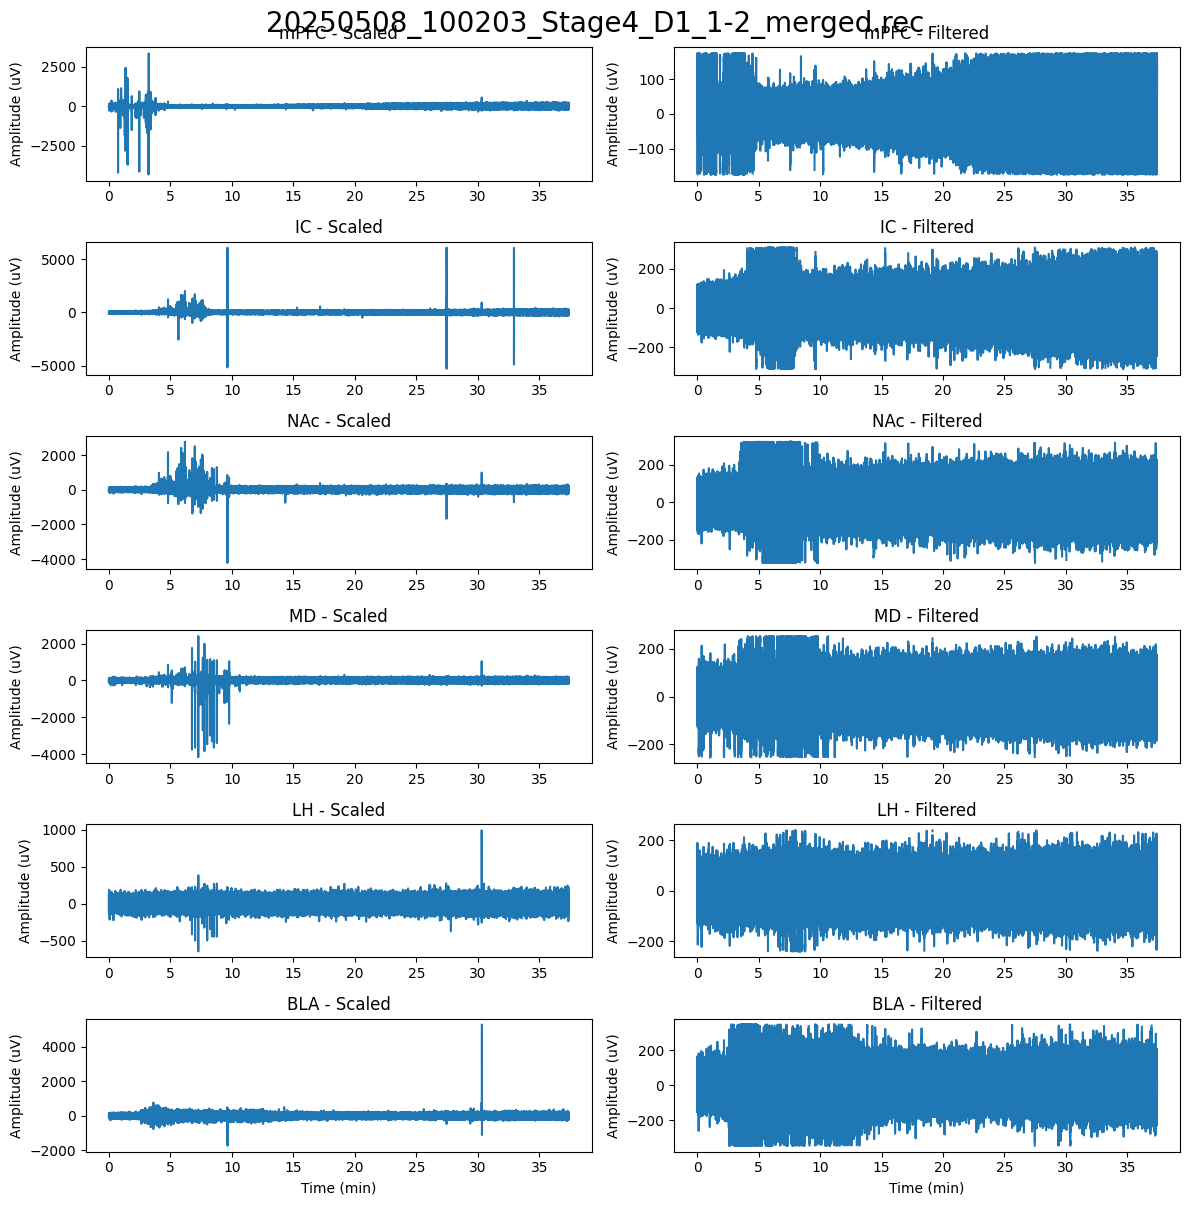

In [9]:
collection.diagnostic_plots(threshold = 5)

In [10]:
# collection.diagnostic_plots_channel_finder()

In [11]:
collection.preprocess(threshold = 5)

  0%|          | 0/1 [00:00<?, ?it/s]

processing 20250508_100203_Stage4_D1_1-2_merged.rec


100%|██████████| 1/1 [00:01<00:00,  1.07s/it]

RMS Traces calculated


In [12]:
collection.calculate_all()



  0%|          | 0/1 [00:00<?, ?it/s]

Power Calculated
Coherence calcualatd


Maximum iterations reached. 2817 of 4487 converged
Maximum iterations reached. 2708 of 4487 converged
Maximum iterations reached. 2893 of 4487 converged
Maximum iterations reached. 3088 of 4487 converged
Maximum iterations reached. 2840 of 4487 converged
Maximum iterations reached. 3927 of 4487 converged
Maximum iterations reached. 3955 of 4487 converged
Maximum iterations reached. 4034 of 4487 converged
Maximum iterations reached. 3789 of 4487 converged
Maximum iterations reached. 3962 of 4487 converged
Maximum iterations reached. 4019 of 4487 converged
Maximum iterations reached. 3820 of 4487 converged
Maximum iterations reached. 4215 of 4487 converged
Maximum iterations reached. 3952 of 4487 converged
Maximum iterations reached. 4081 of 4487 converged
100%|██████████| 1/1 [17:54<00:00, 1074.78s/it]

Granger causality calculated


In [13]:
# collection.save_to_json(r"share/eli_coop_grant/lfp")

In [14]:
from collections import defaultdict
condition_dict = defaultdict(list)
for recording in collection.recordings: 
#     if recording.name == '20250517_121746_Stage8_D8_6-1_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_121746_Stage8_D8_6-3_merged.rec':
#         recording.condition = 'alone'
#         condition_dict['alone'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_2-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-3_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_105306_Stage4_D8_1-2_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-2_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-3_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-4_merged.rec':
#         recording.condition = 'subject'
#         condition_dict['subject'].append(recording.name)
#     if recording.name == '20250517_134054_Stage4_D8_4-1_merged.rec':
#         recording.condition = 'recipient'
#         condition_dict['recipient'].append(recording.name)
#     if recording.name == '20250520_111417_alone_D1_4-2_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-1_merged.rec':
#     if recording.name == '20250520_111417_alone_D1_4-3_merged.rec':
	if recording.name == '20250508_100203_Stage4_D1_1-2_merged.rec':
		recording.condition = 'subject'
		condition_dict['subject'].append(recording.name)

        
print(condition_dict)

defaultdict(<class 'list'>, {'subject': ['20250508_100203_Stage4_D1_1-2_merged.rec']})


In [ ]:
# import numpy as np
# def random_event_generator(start, stop, len_event, no_events):
#     total_duration = stop - start
#     possible_events = np.arange(int(total_duration / len_event))
#     pot_events = np.random.choice(possible_events, size = (no_events), replace = False)
#     pot_events = np.sort(pot_events)
#     events = []
#     for i in pot_events: 
#         event_start = (start + (len_event * i))
#         event_stop = (event_start + (len_event))
#         events.append(np.array([event_start, event_stop]))
#     return(np.array(events))


In [ ]:
# for recording in collection.recordings: 
#     start = 0
#     stop = recording.power.shape[0]*0.5*1000 
#     recording.event_dict = {}
#     random_events = random_event_generator(start, stop, len_event = 10000, no_events = 30)
    
#     recording.event_dict['random event'] = random_events

In [16]:
# os.chdir('/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys')
import lfp.lfp_analysis.event_extraction as ee
def average_events_condition(
    lfp_collection, events, mode, condition_dict, baseline=None, event_len=None, pre_window=0, post_window=0, plot=False, regions = None, freq_range = None):
    """
    Calculates average event measurement (power, coherence, or granger) per recording then
    calculates global averages across all recordings from recording averages (to account for
    differences in event numbers per recording)
    """
    event_averages_dict = {}
    recordings = lfp_collection.recordings
    if baseline is not None:
        if (len(events) != len(baseline)) and (len(baseline) == 1):
            baseline = baseline * len(events)
    for i in range(len(events)):
        for condition, recording_list in condition_dict.items():
            recording_averages = []
            for recording in recordings:
                if recording.name in recording_list:
                    event_averages = ee.get_events(recording, events[i], mode, event_len, pre_window, post_window, average = True)
                    if baseline is not None:
                        adj_averages = ee.__baseline_diff__(
                            recording, event_averages, baseline[i], mode, event_len, pre_window=0, post_window=0, average = True
                        )
                        rec_event_average = np.mean(np.array(adj_averages), axis = 0)
                        recording_averages.append(rec_event_average)
                    else:
                        rec_event_average = np.mean(np.array(event_averages), axis = 0)
                        recording_averages.append(rec_event_average)

                # recording_averages = [recs, b, f] or [recs, b, b, f]
            print(np.array(recording_averages).shape)    
            event_averages_dict[condition] = recording_averages
        if plot:
            lfplt.plot_average_events(lfp_collection, event_averages_dict, mode, regions, freq_range)
        return event_averages_dict
    
condition_coherence = average_events_condition(collection, events = ['selfish light'], mode = 'coherence', condition_dict = condition_dict)
condition_power = average_events_condition(collection, events = ['selfish light'], mode = 'power', condition_dict = condition_dict)

SyntaxError: invalid syntax (event_extraction.py, line 157)

In [ ]:
# del condition_power['recipient']
# del condition_coherence['recipient']

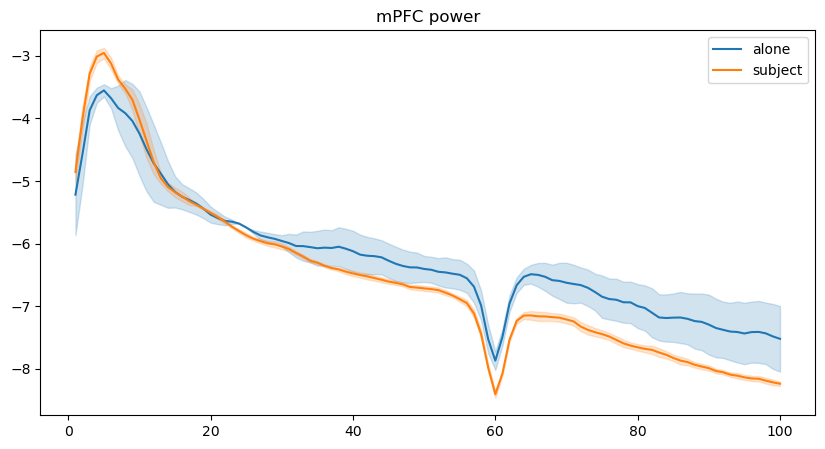

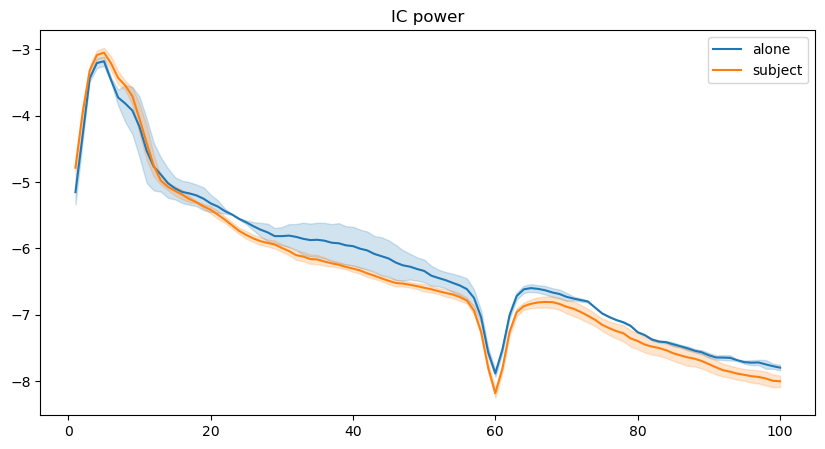

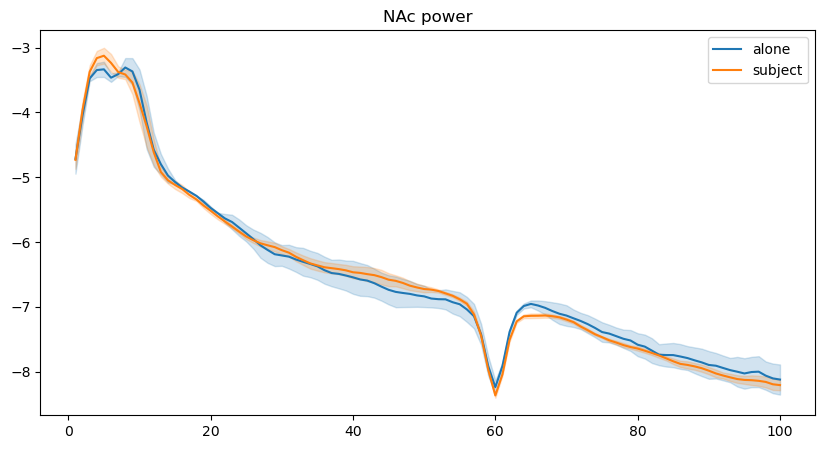

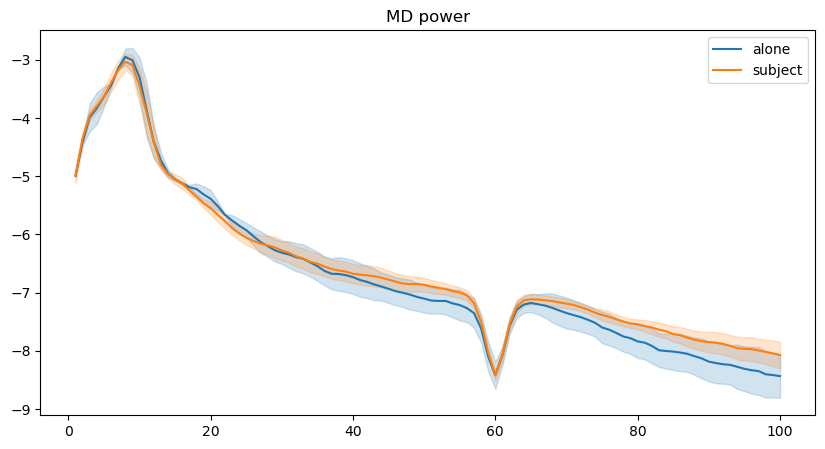

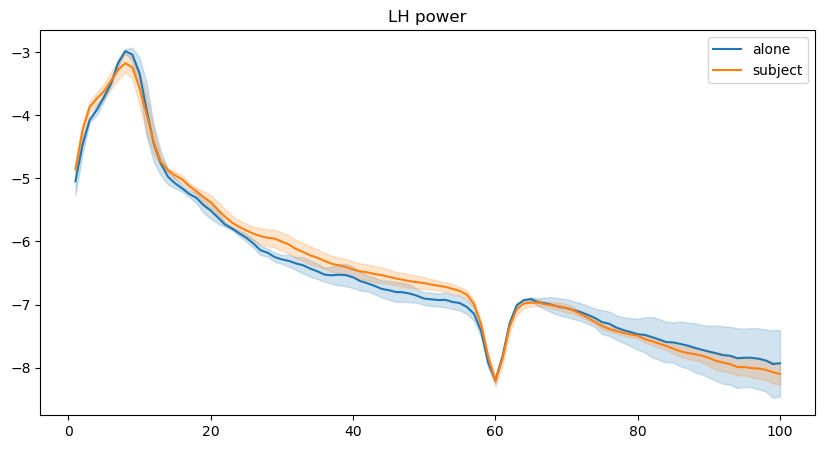

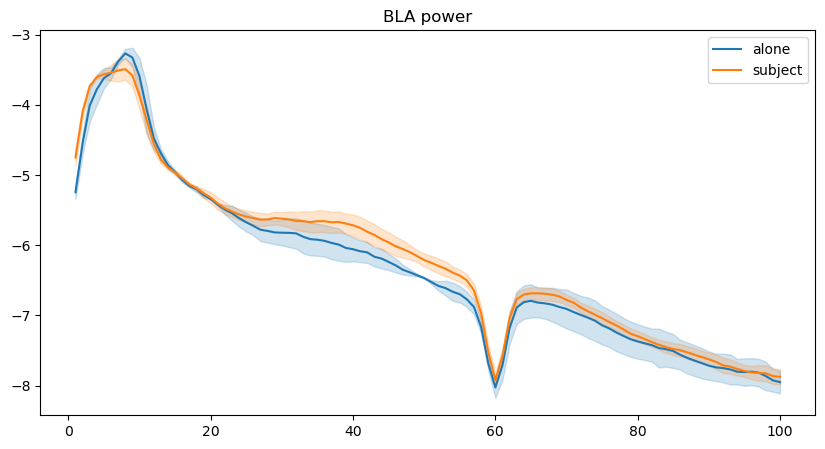

/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys/lfp/lfp_analysis/plotting.py:81: RuntimeWarning: Mean of empty slice
  second_region_name = lfp_collection.brain_region_dict.inverse[second_region]
/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys/lfp/lfp_analysis/plotting.py:84: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  # event_average = [f, b, b]; average across all trials


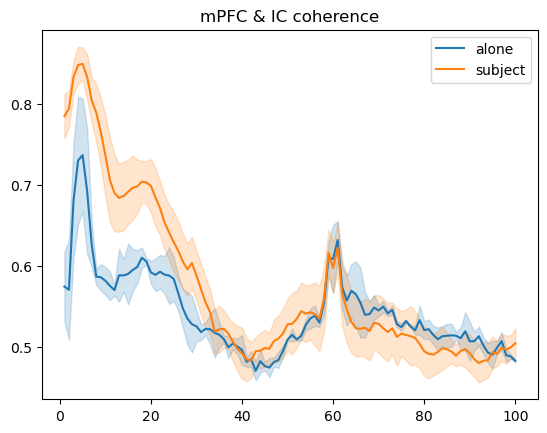

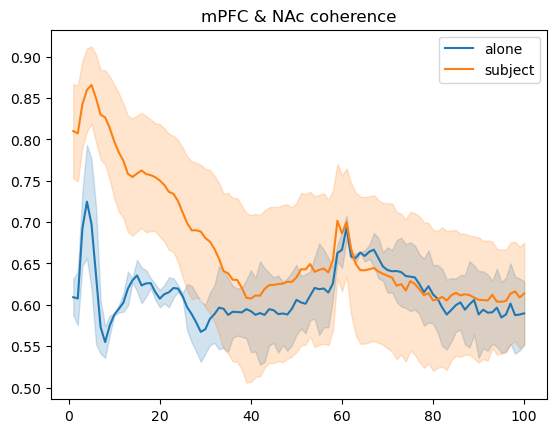

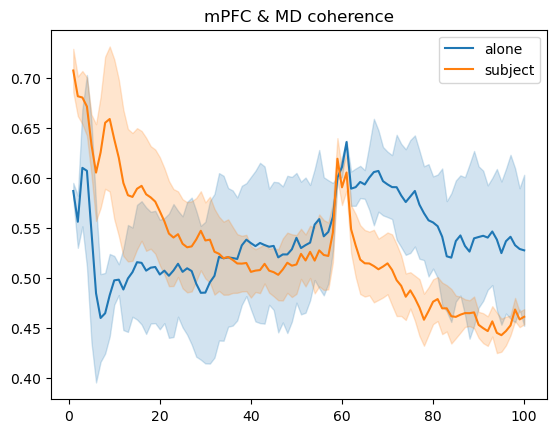

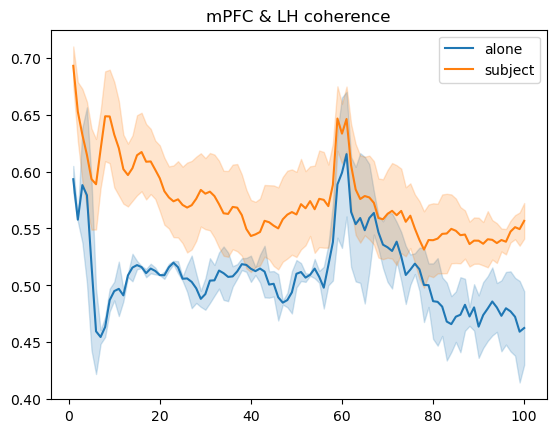

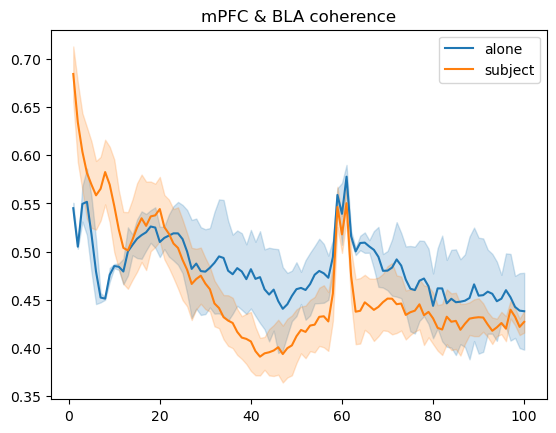

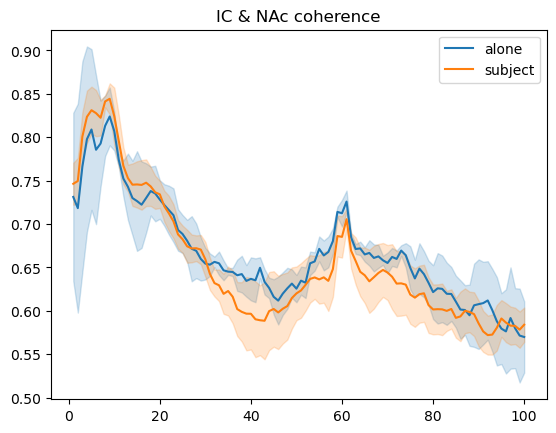

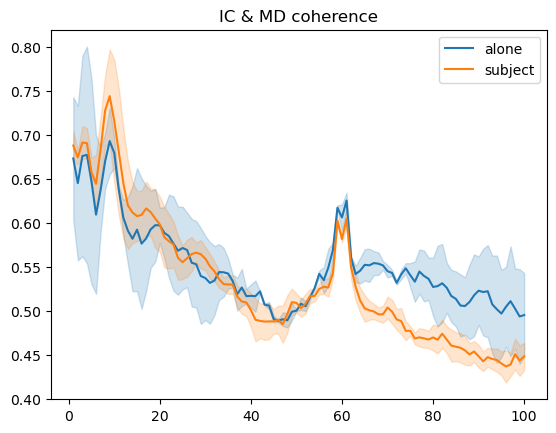

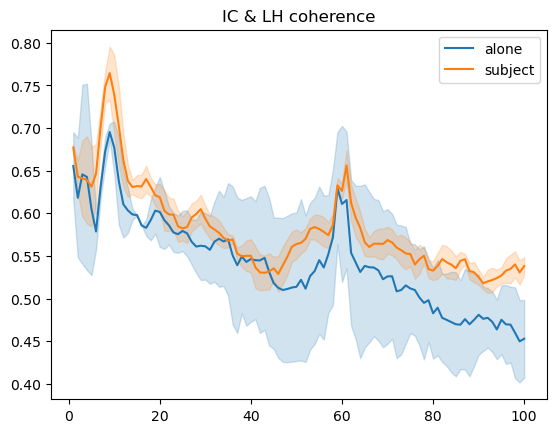

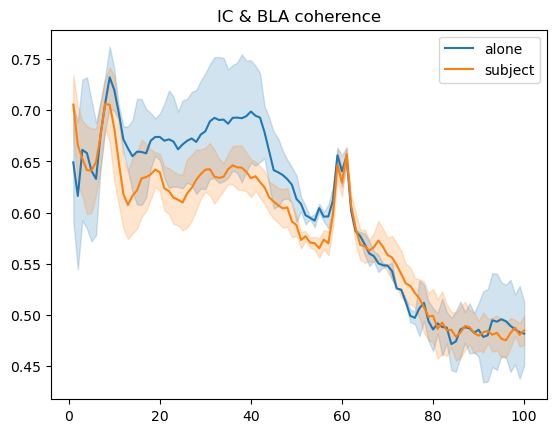

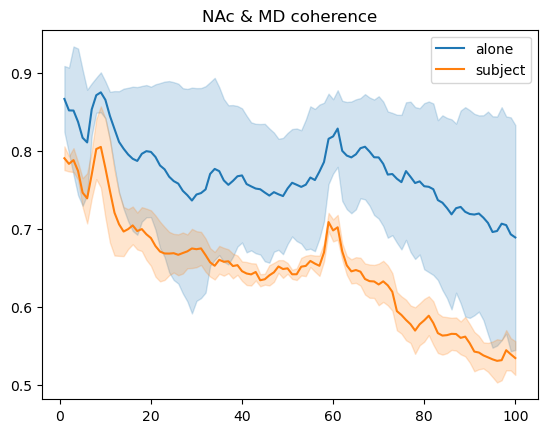

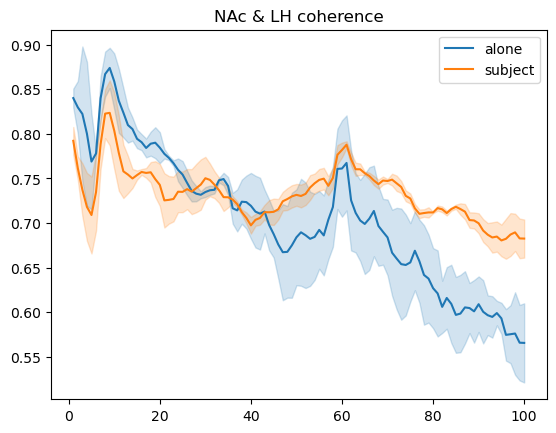

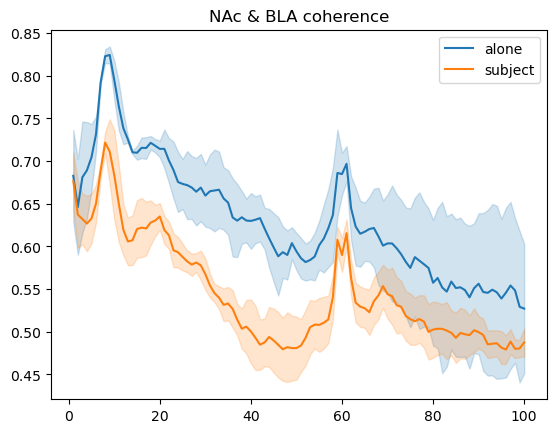

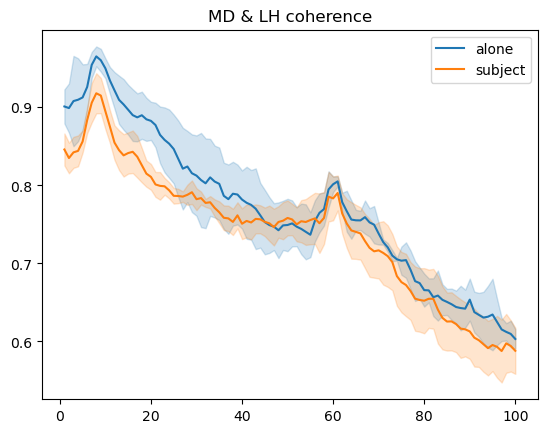

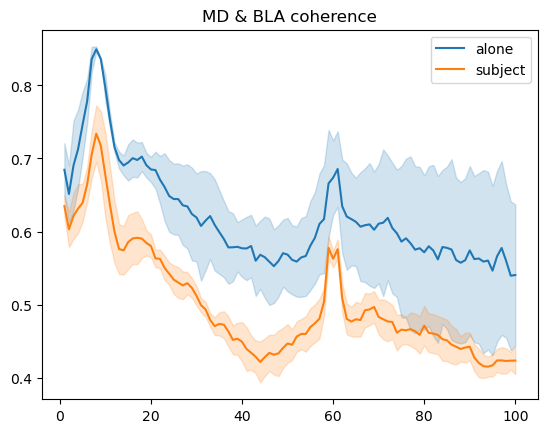

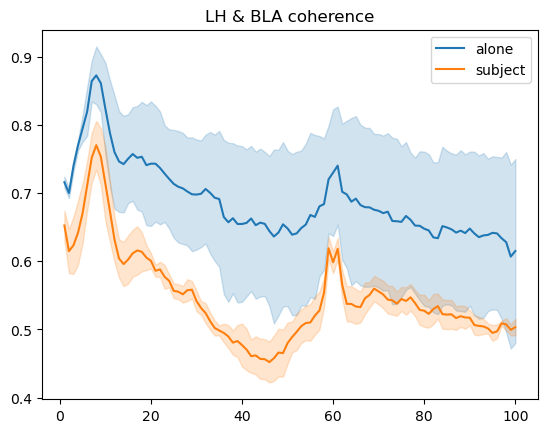

In [ ]:
import lfp.lfp_analysis.plotting as lfplt
from importlib import reload
reload(lfplt)

lfplt.plot_event_spectrum(collection, condition_power, mode = 'power',log = True)
lfplt.plot_event_spectrum(collection, condition_coherence, mode = 'coherence',log = False)

In [ ]:
def event_power_bar(lfp_collection, events, baseline=None):
    powers = ee.average_events(lfp_collection, events=events, mode="power", baseline=baseline, plot=False)
    [unflipped, flipped] = band_calcs(powers)
    brain_regions = np.empty(len(lfp_collection.brain_region_dict.keys()), dtype="<U10")
    for i in range(len(lfp_collection.brain_region_dict.keys())):
        brain_regions[i] = lfp_collection.brain_region_dict.inverse[i]
    avg_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    sem_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
    for key in flipped.keys():
        for i, subset in enumerate(brain_regions):
            for event in events:
                avg_values[key][subset][event] = np.nanmean(flipped[key][event][:, i])
                sem_values[key][subset][event] = stats.sem(flipped[key][event][:, i], nan_policy="omit")

    # Adjust bar width and spacing based on number of events
    total_width = 0.8  # Total width available for each group of bars
    bar_width = total_width / len(events)  # Width of each bar
    col = cm.rainbow(np.linspace(0, 1, len(events)))

    # Spacing between groups of bars
    group_spacing = 1  # Increased for better separation between brain regions

    sorted_avg_values = {key: {subset: avg_values[key][subset] for subset in brain_regions} for key in flipped.keys()}
    sorted_sem_values = {key: {subset: sem_values[key][subset] for subset in brain_regions} for key in flipped.keys()}

    # Create a separate plot for each key
    for key in flipped.keys():
        plt.figure(figsize=(25, 10))
        x = np.arange(len(brain_regions)) * group_spacing  # x-axis positions for subsets

        for i, subset in enumerate(brain_regions):
            for k, event in enumerate(events):
                # Center the group of bars and space them evenly
                center = x[i]
                offset = (k - (len(events) - 1) / 2) * bar_width
                position = center + offset

                plt.bar(
                    position,
                    sorted_avg_values[key][subset][event],
                    width=bar_width,
                    yerr=sorted_sem_values[key][subset][event],
                    capsize=5,
                    linewidth=2,
                    error_kw={"elinewidth": 2, "capthick": 2},
                    color=col[k],
                    label=event if i == 0 else "",
                )

        plt.yticks(fontsize=20)
        plt.xticks(x, brain_regions, fontsize=24, rotation=45)
        plt.axhline(y=0, color="black", linestyle="--", alpha=0.8)
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.gca().spines["bottom"].set_linewidth(2)
        plt.gca().spines["left"].set_linewidth(2)
        plt.title(f"Average Power for {key}", fontsize=40)
        plt.legend(fontsize=26, frameon=False)
        plt.subplots_adjust(hspace=0.5)
        plt.show()
